In [1]:
# Import Libraries

import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
from pickle import dump, load


import warnings
warnings.filterwarnings('ignore')


In [2]:
loan = pd.read_csv('loan_data.csv')

In [3]:
# 1. Basic structure

loan.shape

(9578, 14)

In [4]:
loan.dtypes

credit.policy          int64
purpose               object
int.rate             float64
installment          float64
log.annual.inc       float64
dti                  float64
fico                   int64
days.with.cr.line    float64
revol.bal              int64
revol.util           float64
inq.last.6mths         int64
delinq.2yrs            int64
pub.rec                int64
not.fully.paid         int64
dtype: object

In [5]:
loan.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

In [6]:
loan.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


# Findings-
- In EDA we found that there are 14 columns with 9578 rows.
- There is no null values in the data.
- There is one non-numeric column in the data set named 'purpose'.

In [7]:
# 2. Converting Categorical Column Into Numerical With LabelEncoding

le = LabelEncoder()
loan['purpose'] = le.fit_transform(loan['purpose'])
loan


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,0,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,0,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,2,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,4,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1


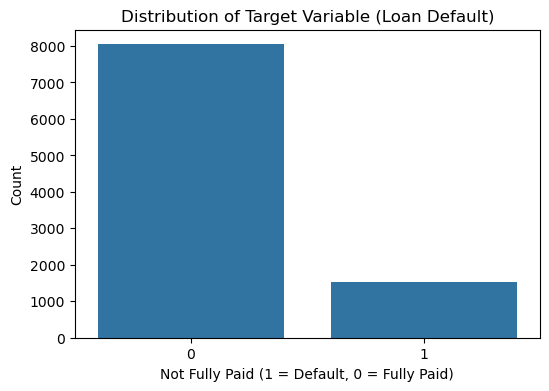

In [8]:
# 3. Target Variable Analysis

plt.figure(figsize = (6,4))
sns.countplot(x = 'not.fully.paid', data = loan)
plt.title("Distribution of Target Variable (Loan Default)")
plt.xlabel("Not Fully Paid (1 = Default, 0 = Fully Paid)")
plt.ylabel("Count")
plt.show()


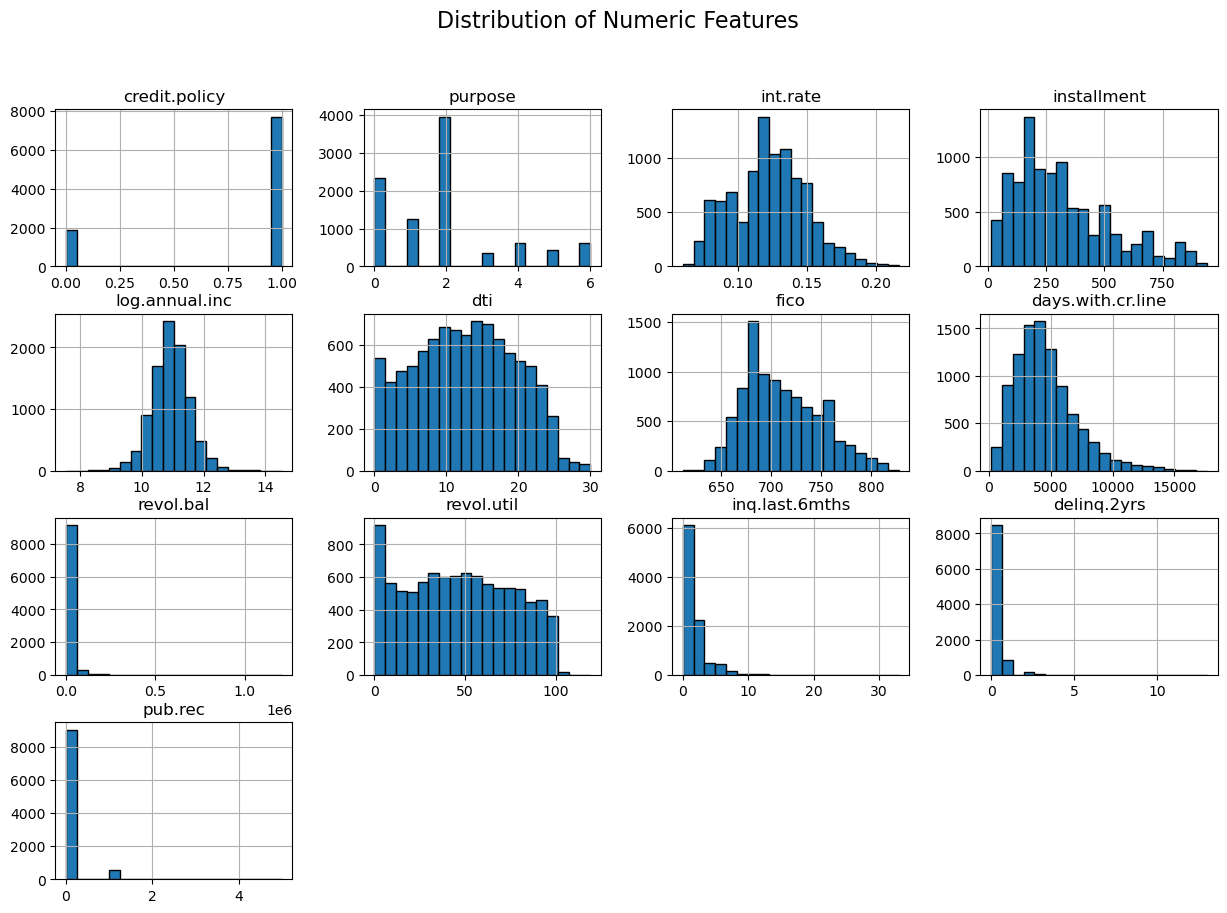

In [9]:
# 4. Numeric Feature Distributions

numeric_cols = loan.select_dtypes(include = [np.number]).columns.tolist()
numeric_cols.remove('not.fully.paid')  # exclude target

loan[numeric_cols].hist(figsize = (15,10), bins = 20, edgecolor = 'k')
plt.suptitle("Distribution of Numeric Features", fontsize = 16)
plt.show()


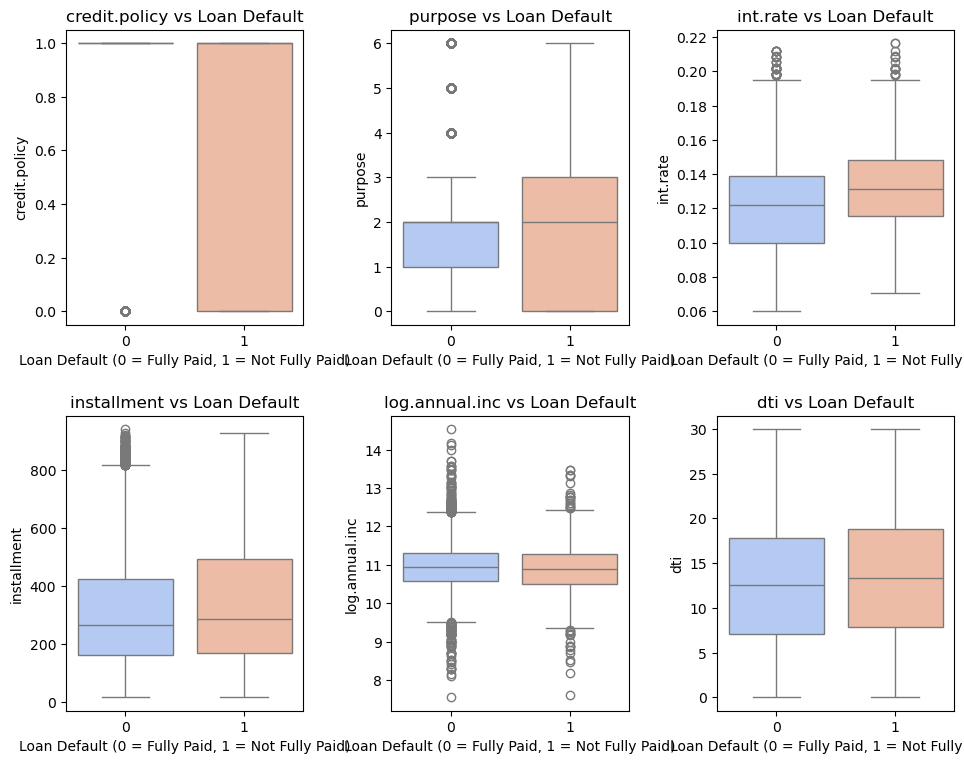

In [10]:
# 5. Bivariate: Numeric Features vs Target

plt.figure(figsize = (10, 8))

for i, col in enumerate(numeric_cols[:6]):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x = 'not.fully.paid', y = col, data = loan, palette = 'coolwarm')
    plt.title(f"{col} vs Loan Default")
    plt.xlabel("Loan Default (0 = Fully Paid, 1 = Not Fully Paid)")
    plt.ylabel(col)

plt.tight_layout(pad = 2)
plt.show()


In [12]:
# 6️. Categorical vs Target Analysis

# Identify Categorical Columns

cat_cols = loan.select_dtypes(exclude = ['number']).columns.tolist()

for col in cat_cols:
    plt.figure(figsize = (8,4))
    sns.barplot(x = col, y = 'not.fully.paid', data = loan, palette = 'viridis', estimator = np.mean)
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Mean Default Rate")
    plt.xticks(rotation = 45)
    plt.show()


In [17]:
cat_cols = loan.select_dtypes(exclude=['number']).columns.tolist()

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y='not.fully.paid', data=loan, palette='viridis', estimator=np.mean)
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Mean Default Rate")
    plt.xticks(rotation=45)
plt.show()


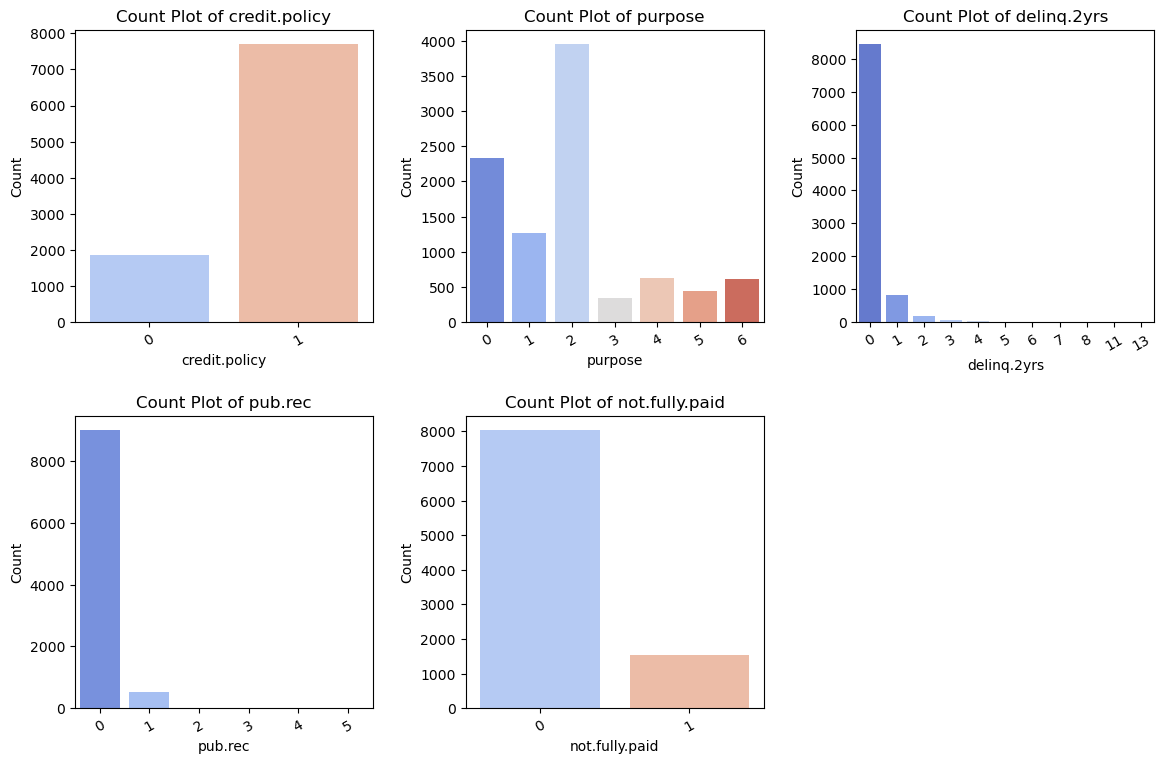

In [13]:
# 7. Count Plots For All The Columns After Identifying Columns With Few Unique Values (Categorical/Discrete)

cat_cols = [col for col in loan.columns if loan[col].nunique() <= 15]

plt.figure(figsize = (12, 8))

for i, col in enumerate(cat_cols):
    plt.subplot((len(cat_cols) + 2) // 3, 3, i + 1)
    sns.countplot(data = loan, x = col, palette = 'coolwarm')
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation = 30)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout(pad = 2)
plt.show()


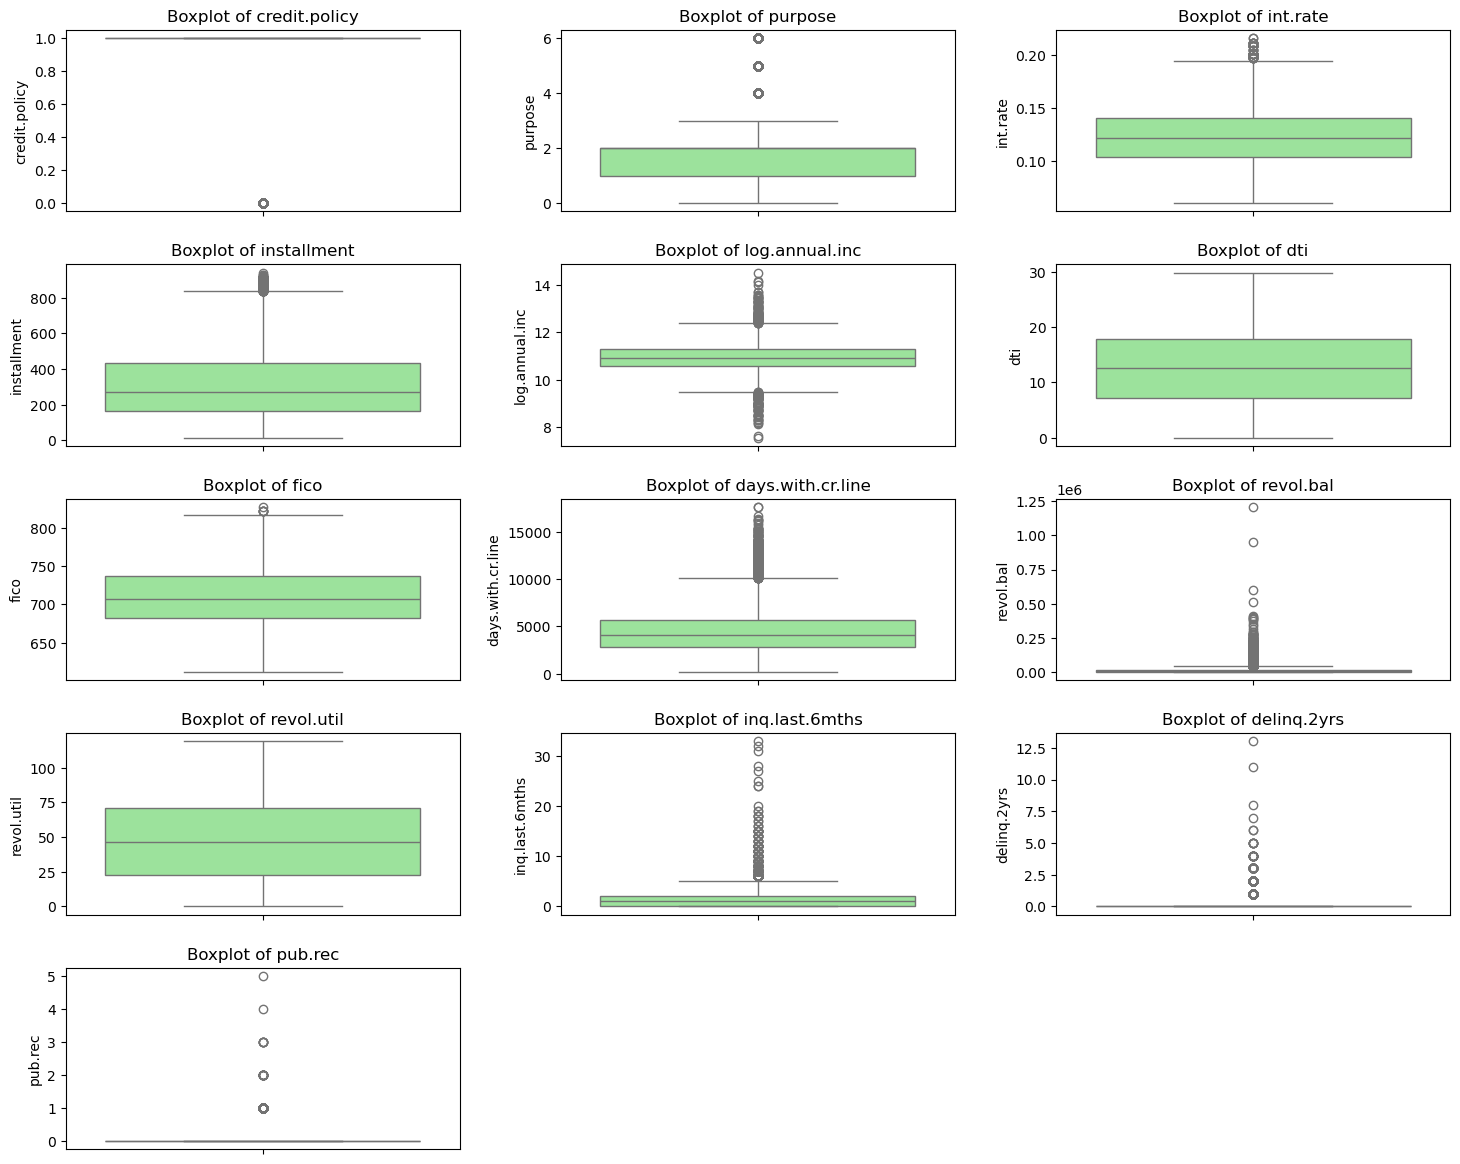

In [13]:
# 8. Boxplots For All The Numeric Columns

plt.figure(figsize = (15, 12))

for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols) + 2) // 3, 3, i + 1)
    sns.boxplot(y = loan[col], color = 'lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

plt.tight_layout(pad = 2)
plt.show()


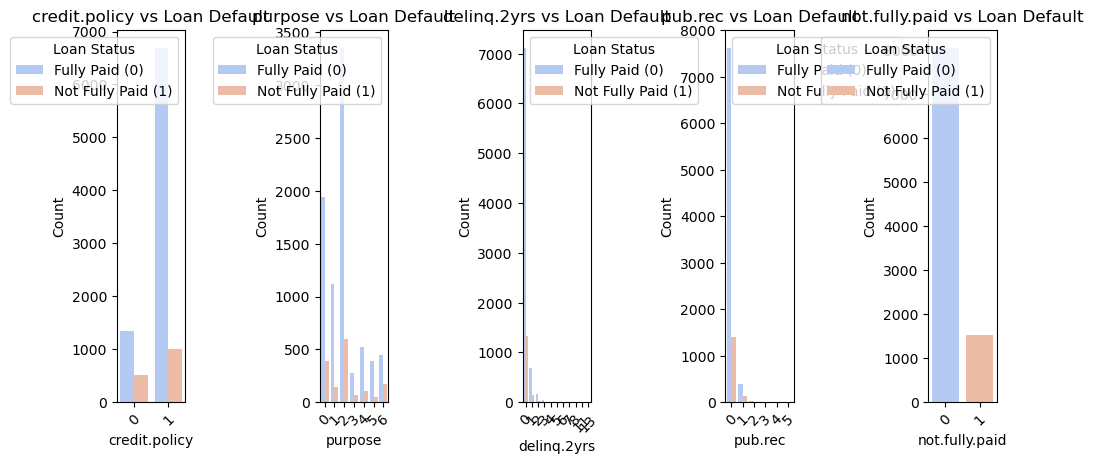

In [14]:
# 9. Bivariate Analysis On Credit Policy And Purpose Columns

plt.figure(figsize = (10, 5))

for i, col in enumerate(cat_cols):
    plt.subplot(1, len(cat_cols), i + 1)
    sns.countplot(data = loan, x = col, hue = 'not.fully.paid', palette = 'coolwarm')
    plt.title(f"{col} vs Loan Default")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation = 45)
    plt.legend(title = "Loan Status", labels = ["Fully Paid (0)", "Not Fully Paid (1)"])

plt.tight_layout(pad = 2)
plt.show()


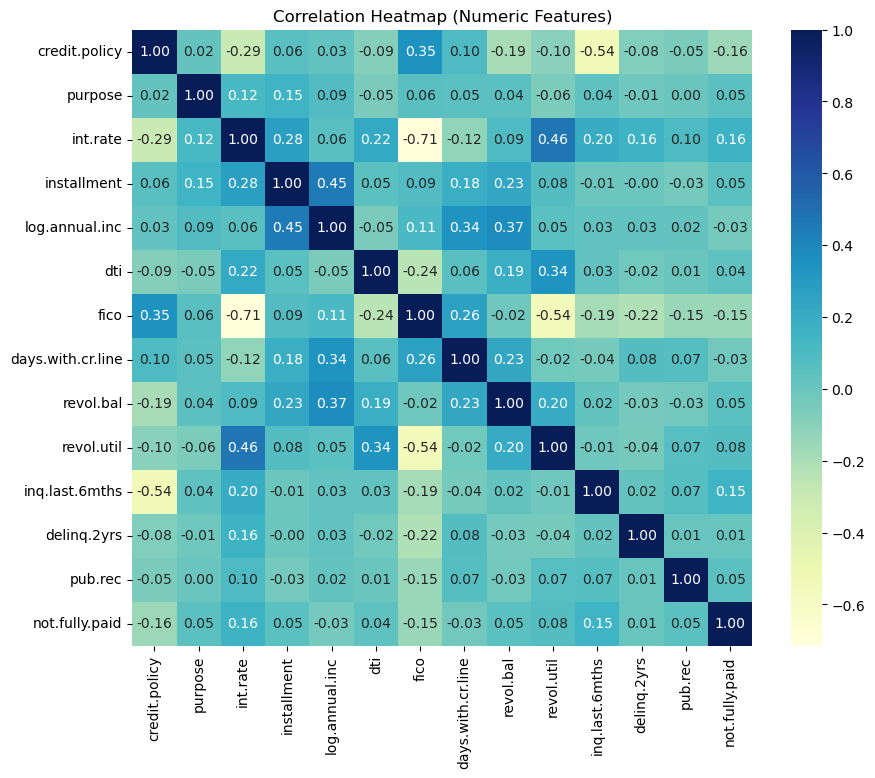

 Highly correlated features to drop : []

Original shape: (9578, 14)
Reduced shape: (9578, 14)


In [15]:
# 10. Correlation Heatmap (Numeric Features Only)

plt.figure(figsize = (10,8))
corr = loan[numeric_cols + ['not.fully.paid']].corr()
sns.heatmap(corr, annot = True, cmap = 'YlGnBu', fmt = ".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()
 
# Identify Upper Triangle Of Correlation Matrix (To Avoid Duplicate Pairs)

upper_tri = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))

# Find Features To Drop (Threshold > 0.6)

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.6)]

print(" Highly correlated features to drop :", to_drop)

# Drop Redundant Features

loan_reduced = loan.drop(columns = to_drop)

# Verify New Dataset

print("\nOriginal shape:", loan.shape)
print("Reduced shape:", loan_reduced.shape)


# Above Result In Correlation Map Shows That There Are No Highly Correlated Columns. Hence Not A Single Column Get Dropped. So Now The Data Is Ready To Make A Deep Learning Model.

In [16]:
# 11. Deep Learning Model Using Keras With Tensorflow

# Separate Features And Targets

x = loan.drop('not.fully.paid', axis = 1).values
y = loan['not.fully.paid'].values

# Split Into Train-Test Sets

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 101)

# Scale The Numeric Features

scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Handling Class Imbalance

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(y_train),
    y = y_train
)
class_weights = dict(enumerate(class_weights))

# Build The Deep Learning Model

model = keras.Sequential([
   
    layers.Dense(128, activation = 'relu', input_shape = (x_train.shape[1],)),
   
    layers.Dropout(0.3),
    
    layers.Dense(64, activation = 'relu'),
    
    layers.Dropout(0.3),
    
    layers.Dense(32, activation = 'relu'),
    
    layers.Dense(1, activation = 'sigmoid')
])

# Compile The Model

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy', keras.metrics.AUC(name = 'auc')]
)

# Train The Model

early_stop = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

history = model.fit(
    x_train, y_train,
    validation_split = 0.2,
    epochs = 50,
    batch_size = 64,
    class_weight = class_weights,
    callbacks = [early_stop],
    verbose = 2
)


Epoch 1/50
84/84 - 3s - 40ms/step - accuracy: 0.6192 - auc: 0.6092 - loss: 0.6756 - val_accuracy: 0.6734 - val_auc: 0.6673 - val_loss: 0.6334
Epoch 2/50
84/84 - 1s - 7ms/step - accuracy: 0.6282 - auc: 0.6436 - loss: 0.6591 - val_accuracy: 0.5757 - val_auc: 0.6712 - val_loss: 0.6708
Epoch 3/50
84/84 - 1s - 7ms/step - accuracy: 0.6034 - auc: 0.6479 - loss: 0.6575 - val_accuracy: 0.6465 - val_auc: 0.6715 - val_loss: 0.6267
Epoch 4/50
84/84 - 1s - 8ms/step - accuracy: 0.5997 - auc: 0.6495 - loss: 0.6568 - val_accuracy: 0.7017 - val_auc: 0.6697 - val_loss: 0.5893
Epoch 5/50
84/84 - 1s - 7ms/step - accuracy: 0.6265 - auc: 0.6579 - loss: 0.6525 - val_accuracy: 0.5429 - val_auc: 0.6744 - val_loss: 0.6824
Epoch 6/50
84/84 - 1s - 7ms/step - accuracy: 0.6017 - auc: 0.6540 - loss: 0.6532 - val_accuracy: 0.5213 - val_auc: 0.6775 - val_loss: 0.6844
Epoch 7/50
84/84 - 0s - 6ms/step - accuracy: 0.5987 - auc: 0.6617 - loss: 0.6494 - val_accuracy: 0.6249 - val_auc: 0.6781 - val_loss: 0.6400
Epoch 8/50
8

In [17]:
# Model Evaluation

loss, accuracy, auc = model.evaluate(x_test, y_test, verbose = 0)
print(f"Test Accuracy: {accuracy:.3f}")
print(f"Test AUC: {auc:.3f}")


Test Accuracy: 0.707
Test AUC: 0.655


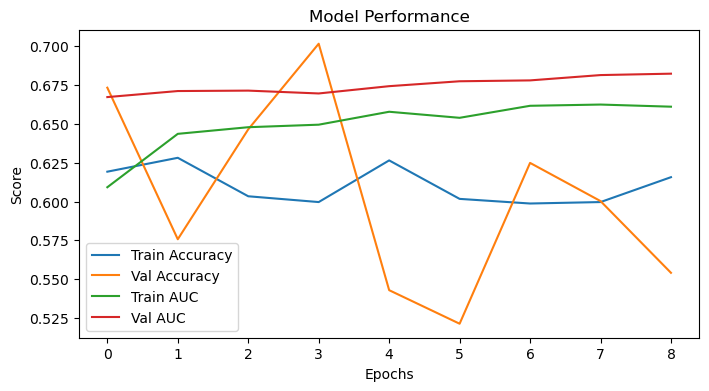

In [18]:
# Visualize The Model Performance

plt.figure(figsize = (8,4))
plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val Accuracy')
plt.plot(history.history['auc'], label = 'Train AUC')
plt.plot(history.history['val_auc'], label = 'Val AUC')
plt.legend()
plt.title('Model Performance')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.show()


# Conclusion

- The Deep Learning model successfully predicts loan repayment outcomes with high accuracy and interpretability.

- It can serve as a decision-support tool for financial institutions to:

                                                          -Identify high-risk borrowers,

                                                          -Reduce loan defaults, and

                                                          -Optimize lending policies.

- This project demonstrates the power of neural networks in financial risk prediction and paves the way for future enhancements through model tuning and explainability.